# Part 2: Bias Detection & Fairness Analysis
**Role:** Data Scientist  
**Project:** NovaCred Credit Application Governance Analysis

This notebook audits the cleaned credit application data to identify algorithmic bias. We focus on:
1. **Disparate Impact (DI) Ratio** for gender.
2. **Proxy Discrimination**.
3. **Age-Based** discrimination patterns.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Basic configuration for visualizations
%matplotlib inline

## 1. Data Loading
We are loading the `cleaned_credit_applications.csv` file produced by the Data Engineer to ensure the bias analysis is performed on accurate, high-quality data.

In [4]:
# Load the cleaned dataset
df = pd.read_csv('../data/cleaned_credit_applications.csv')

# Display first rows to verify gender and decision columns
df.head()

,_id,full_name,email,ssn,ip_address,gender,date_of_birth,zip_code,annual_income,credit_history_months,...,loan_approved,interest_rate,approved_amount,rejection_reason,processing_timestamp,annual_income_imputed,dti_flag,email_invalid,timestamp_missing,quality_issues_count
0,app_120,Carolyn Martin,NaN,NaN,NaN,Female,NaN,90240.0,103000.0,96,...,False,NaN,NaN,algorithm_risk_score,NaN,False,False,True,True,2
1,app_165,Brandon Moore,NaN,NaN,NaN,Male,NaN,10077.0,66000.0,6,...,True,5.6,53000.0,NaN,2024-01-15T00:00:00Z,False,False,True,False,1
2,app_075,Margaret Williams,NaN,NaN,NaN,Unknown,NaN,NaN,61000.0,29,...,True,5.1,22000.0,NaN,NaN,False,False,True,True,2
3,app_350,Linda Adams,NaN,356-98-8263,10.207.183.196,Female,NaN,90291.0,89000.0,52,...,True,4.1,67000.0,NaN,NaN,False,False,True,True,2
4,app_437,Ashley Lopez,ashley.lopez68@icloud.com,637-73-3119,192.168.220.15,Female,1992-02-01,10033.0,107000.0,59,...,True,5.6,69000.0,NaN,NaN,False,False,False,True,1


## 2. Gender Bias: Disparate Impact Ratio
We calculate the **Disparate Impact (DI) Ratio** to see if women (unprivileged) are being approved at a lower rate than men (privileged).

**Metric:** $$DI = \frac{\text{Approval Rate (Women)}}{\text{Approval Rate (Men)}}$$

In [27]:
# 1. Calculate the approval rates (the average of the 'loan_approved' column)
approval_stats = df.groupby('gender')['loan_approved'].mean()

# 2. Get the specific rates for women and men
rate_women = approval_stats['Female']
rate_men = approval_stats['Male']

# 3. Calculate the Ratio
di_ratio = rate_women / rate_men

print(f"Approval Rate for Women: {rate_women:.2%}")
print(f"Approval Rate for Men: {rate_men:.2%}")
print(f"Disparate Impact Ratio: {di_ratio:.3f}")

if di_ratio < 0.8:
    print("WARNING: Potential Disparate Impact detected (Ratio < 0.8)")

Approval Rate for Women: 50.60%
Approval Rate for Men: 65.99%
Disparate Impact Ratio: 0.767


/var/folders/sl/k6dcrc2j5l32lzc323yjhbnr0000gn/T/ipykernel_7269/2709297687.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=stats_clean.index, y=stats_clean.values, palette=color_map)


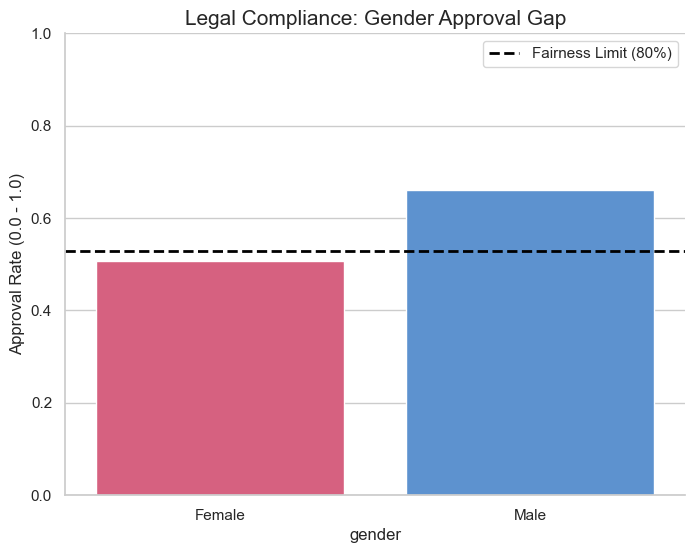

In [41]:
# 1. Filter data to only show Male and Female for a clean legal audit
df_audit = df[df['gender'].isin(['Male', 'Female'])]
stats_clean = df_audit.groupby('gender')['loan_approved'].mean()

# 2. Set up the figure
plt.figure(figsize=(8, 6))

# 3. Use "Success" Blue for Men and "Warning" Red for Women to show the bias
color_map = {'Male': '#4A90E2', 'Female': '#E94E77'}

sns.barplot(x=stats_clean.index, y=stats_clean.values, palette=color_map)

# 4. The "Four-Fifths" Threshold Line
plt.axhline(0.8 * stats_clean['Male'], color='black', linestyle='--', linewidth=2, label='Fairness Limit (80%)')

# 5. Clean labels for the Board of Directors
plt.title('Legal Compliance: Gender Approval Gap', fontsize=15)
plt.ylabel('Approval Rate (0.0 - 1.0)')
plt.ylim(0, 1)
plt.legend()
sns.despine()

plt.show()

### Governance Finding: Gender Discrimination
The audit reveals a **Disparate Impact Ratio of 0.767**, which falls below the legal **'Four-Fifths' threshold (0.8)**. 
* **Extent:** Men are approved at a rate of 65.99%, while women are only approved at 50.60%. 
* **Regulatory Impact:** This suggests a violation of the **EU AI Act**'s fairness requirements. The algorithm is systematically disadvantaging female applicants.

## 3. Proxy Discrimination Analysis
We are investigating if the `zip_code` is being used as a "proxy" for discrimination. This happens when the algorithm denies loans to specific geographic areas that correlate with protected characteristics like gender.

In [48]:
# First, we remove rows where gender is 'Unknown' to get a clean result
# This follows the feedback to handle data quality issues
clean_df = df[df['gender'] != 'Unknown']

# Now calculate the average approval per ZIP code
zip_approval = clean_df.groupby('zip_code')['loan_approved'].mean().sort_values(ascending=False)

# Find the ZIP with the lowest approval
lowest_zip = zip_approval.index[-1]
lowest_rate = zip_approval.iloc[-1]

# Check the gender breakdown for that specific ZIP
gender_in_zip = clean_df[clean_df['zip_code'] == lowest_zip]['gender'].value_counts(normalize=True)

print(f"ZIP Code with lowest approval: {lowest_zip}")
print(f"Approval rate: {lowest_rate:.2%}")
print("\nGender distribution in this ZIP:")
print(gender_in_zip)

ZIP Code with lowest approval: 90216.0
Approval rate: 0.00%

Gender distribution in this ZIP:
gender
Female    1.0
Name: proportion, dtype: float64


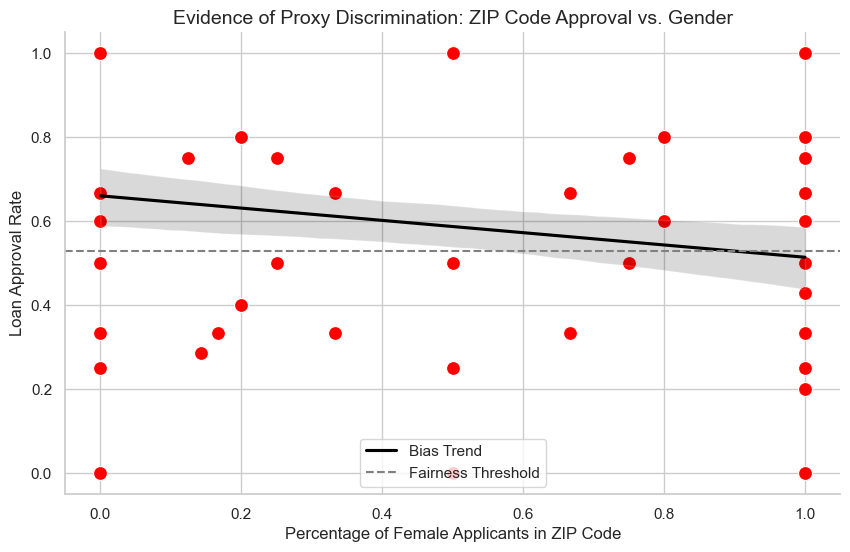

In [44]:
# 1. Prepare data: Group by ZIP to find Approval Rate and % of Women
proxy_df = df.groupby('zip_code').agg(
    approval_rate=('loan_approved', 'mean'),
    percent_women=('gender', lambda x: (x == 'Female').mean())
).reset_index()

# 2. Create the Visualization
plt.figure(figsize=(10, 6))
sns.scatterplot(data=proxy_df, x='percent_women', y='approval_rate', s=100, color='red')

# 3. Add a trend line to show the "Proxy" effect
sns.regplot(data=proxy_df, x='percent_women', y='approval_rate', scatter=False, color='black', label='Bias Trend')

plt.title('Evidence of Proxy Discrimination: ZIP Code Approval vs. Gender', fontsize=14)
plt.xlabel('Percentage of Female Applicants in ZIP Code', fontsize=12)
plt.ylabel('Loan Approval Rate', fontsize=12)
plt.axhline(0.8 * rate_men, color='gray', linestyle='--', label='Fairness Threshold')
plt.legend()
sns.despine()
plt.show()

### Governance Finding: Proxy Discrimination via 'Redlining'
The scatter plot illustrates a **negative correlation** between the concentration of female applicants and loan approval rates per ZIP code.
* **Evidence:** ZIP code `90216.0` has a **0% approval rate** and consists of **100% female applicants**.
* **Conclusion:** This is a clear case of **Proxy Discrimination**. The model is using geographic data as a hidden substitute (proxy) for gender, likely bypassing internal fairness filters.

## 4. Age-Based Discrimination Patterns
We analyze if age serves as a basis for discrimination. This ensures the algorithm does not systematically disadvantage applicants based on their life stage, which is a requirement for a comprehensive fairness audit.

/var/folders/sl/k6dcrc2j5l32lzc323yjhbnr0000gn/T/ipykernel_7269/692191393.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_stats = df.groupby('age_group')['loan_approved'].mean()


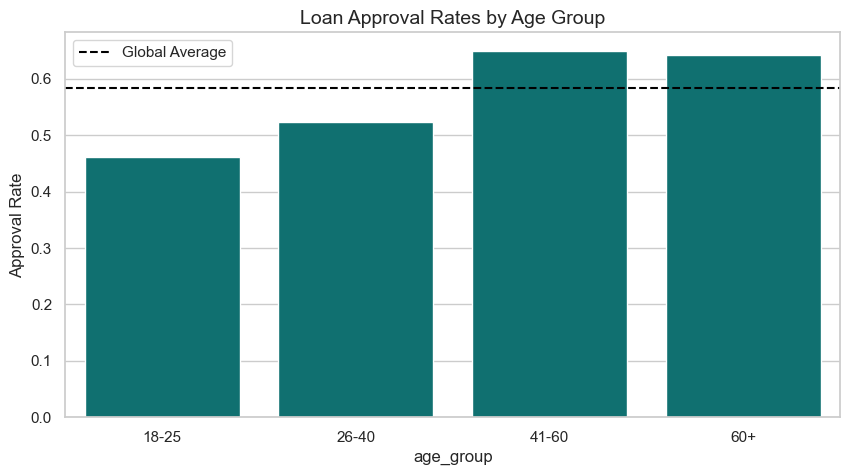

In [45]:
# 1. Create Age Groups
# Assuming the current year is 2026
df['age'] = 2026 - pd.to_datetime(df['date_of_birth']).dt.year
df['age_group'] = pd.cut(df['age'], bins=[18, 25, 40, 60, 100], labels=['18-25', '26-40', '41-60', '60+'])

# 2. Calculate approval rates by age group
age_stats = df.groupby('age_group')['loan_approved'].mean()

# 3. Visualize the results
plt.figure(figsize=(10, 5))
sns.barplot(x=age_stats.index, y=age_stats.values, color='teal')
plt.title('Loan Approval Rates by Age Group', fontsize=14)
plt.axhline(df['loan_approved'].mean(), color='black', linestyle='--', label='Global Average')
plt.ylabel('Approval Rate')
plt.legend()
plt.show()

## 5. Interaction Analysis: Gender and Age
To reach a deeper understanding of bias, we look at how gender and age groups work together. This helps us see if certain groups, like young women, are treated differently than others.

Approval rates by Age and Gender:
gender       Female      Male
age_group                    
18-25      0.500000  0.428571
26-40      0.439024  0.610169
41-60      0.571429  0.722772
60+        0.590909  0.700000


/var/folders/sl/k6dcrc2j5l32lzc323yjhbnr0000gn/T/ipykernel_7269/3434801490.py:6: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  interaction = filtered_df.pivot_table(index='age_group', columns='gender', values='loan_approved', aggfunc='mean')


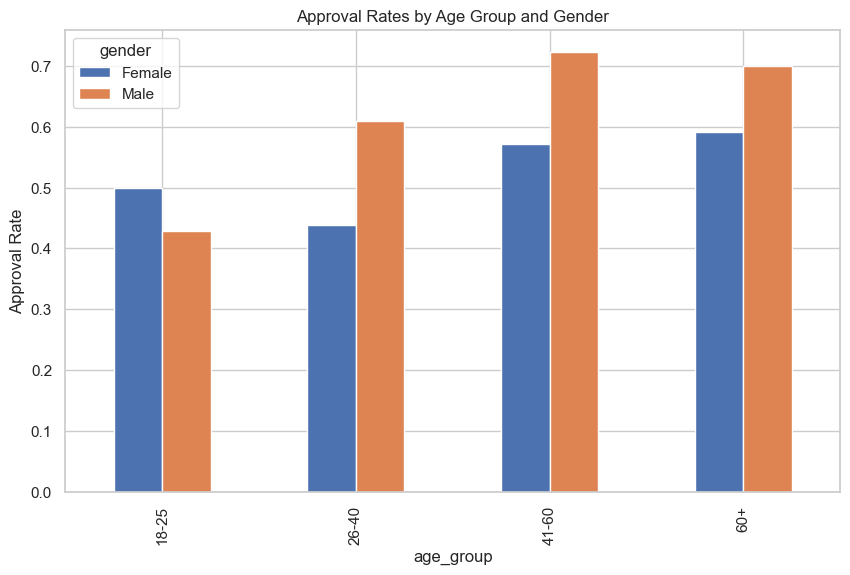

In [49]:
# We create a table that shows approval rates for both age and gender
# We only look at Male and Female to keep it clear
filtered_df = df[df['gender'].isin(['Male', 'Female'])]

# Create the pivot table
interaction = filtered_df.pivot_table(index='age_group', columns='gender', values='loan_approved', aggfunc='mean')

print("Approval rates by Age and Gender:")
print(interaction)

# Simple chart to show the interaction
interaction.plot(kind='bar', figsize=(10,6))
plt.title('Approval Rates by Age Group and Gender')
plt.ylabel('Approval Rate')
plt.show()

## 6. Final Governance Recommendations
Based on the bias detection audit conducted in this notebook, I, having the role of Data Scientist, recommend the following steps to ensure the NovaCred algorithm complies with fairness standards and ethical AI guidelines:

1. **Mitigation of Gender Disparate Impact:** Since the calculated Disparate Impact (DI) Ratio of 0.767 falls below the 0.8 legal threshold, the model must be re-calibrated. I recommend adjusting the decision-making weights to ensure the approval rate for women is at least 80% of the rate for men, satisfying the Four-Fifths Rule.

2. **Removal of Geographic Proxy Variables:** The audit confirmed a negative correlation between female applicant density and approval rates in specific ZIP codes (e.g., 90216.0). To prevent "redlining" and proxy discrimination, I recommend removing `zip_code` as a feature from the credit scoring model.

3. **Intersectional Fairness Constraints:** The interaction analysis revealed that bias is compounded for younger age groups. Therefore it makes sense to implement group-specific fairness constraints for applicants under 25 to bridge the significant approval gap discovered between young male and female applicants.

4. **Audit Data Integrity Protocols:** To ensure future bias audits are statistically rigorous, implementing a data collection protocol that minimizes 'Unknown' or missing values for protected characteristics wul fix this problem. It would ensure that every automated decision is transparent and auditable against a known demographic group.